# Whale Heart Rates

**Category:** Data Modeling  
**Dataset:** blue-whale-heart-rates.csv - 1,087 rows, 8 dives, 32.8% missing heart rate values  
**Objective:** Determine whether longer dives predict a higher heart-rate
spike upon surfacing, using multi-step time-series feature engineering.

---

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
from src.linear_model import LinearModel

df = pd.read_csv('../data/blue-whale-heart-rates.csv')
df.head(10)

,timestamp,heart_rate,dive_id,dive_phase
0,8/27/18 17:10:10,NaN,2,descent
1,8/27/18 17:10:22,5.24,2,descent
2,8/27/18 17:10:31,6.55,2,descent
3,8/27/18 17:10:40,NaN,2,descent
4,8/27/18 17:10:48,NaN,2,descent
5,8/27/18 17:10:56,NaN,2,descent
6,8/27/18 17:11:06,NaN,2,descent
7,8/27/18 17:11:17,NaN,2,descent
8,8/27/18 17:11:20,NaN,2,descent
9,8/27/18 17:11:23,NaN,2,descent


## 1. Dataset Exploration

Checking whether missingness is spread evenly across dive phases, or concentrated in specific ones, before trusting any phase-level average.

In [7]:
print("Shape:", df.shape)
print()
print("Missing Heart-Rate Values:", df['heart_rate'].isnull().sum())
print()
print("Percent Missing:", df['heart_rate'].isnull().mean()*100)
print()
print("Unique Dive IDs:", df['dive_id'].unique())
print()
print("Unique Dive Phases:", df['dive_phase'].unique())

Shape: (1087, 4)

Missing Heart-Rate Values: 357

Percent Missing: 32.842686292548294

Unique Dive IDs: [ 2  3  4  5  7 10 11 13]

Unique Dive Phases: <StringArray>
['descent', 'lunge', 'filter', 'ascent', 'surface']
Length: 5, dtype: str


In [9]:
missing_by_phase = df.groupby('dive_phase')['heart_rate'].apply(lambda s: s.isnull().mean()*100)
print("Percent missing heart_rate, by dive phase:")
print(missing_by_phase.sort_values(ascending=False))

Percent missing heart_rate, by dive phase:
dive_phase
surface    40.592334
descent    31.460674
lunge      31.081081
ascent     23.344948
filter      9.523810
Name: heart_rate, dtype: float64


## 2. Warm-Up: Average Heart Rate by Dive Phase

Computing the average heart rate for each dive phase to understand how
it changes throughout a dive before engineering dive-level features.

In [10]:
phase_avg = df.groupby('dive_phase')['heart_rate'].agg(['mean', 'count']).sort_values('mean')
phase_avg

,mean,count
dive_phase,,
filter,6.561053,57
descent,7.473607,61
lunge,9.773529,51
ascent,20.433318,220
surface,32.546041,341


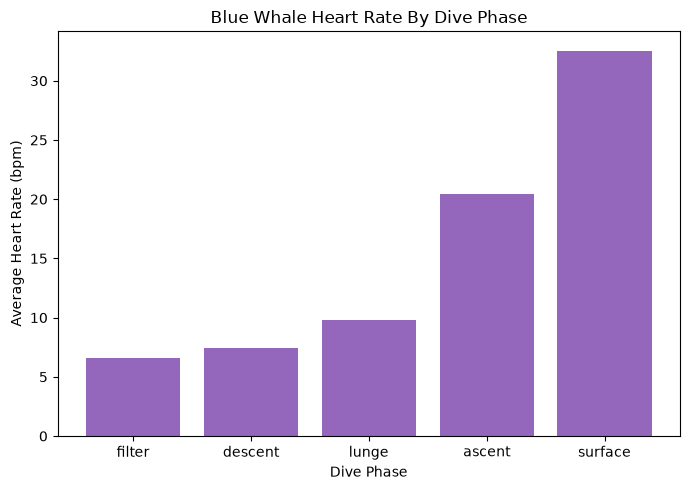

Chart Saved.


In [15]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(phase_avg.index, phase_avg['mean'], color='C4')
ax.set_xlabel('Dive Phase')
ax.set_ylabel('Average Heart Rate (bpm)')
ax.set_title('Blue Whale Heart Rate By Dive Phase')

plt.tight_layout()

plt.savefig('../images/plots/heart_rate_by_dive_phase.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart Saved.")

## 3. Parsing Timestamps

Inspecting the raw timestamp format before parsing. Using an explicit
datetime format ensures accurate conversion and avoids slower automatic
format detection.

In [16]:
print(df['timestamp'].head().tolist())
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%m/%d/%y %H:%M:%S')
df[['timestamp']].head()

['8/27/18 17:10:10', '8/27/18 17:10:22', '8/27/18 17:10:31', '8/27/18 17:10:40', '8/27/18 17:10:48']


,timestamp
0,2018-08-27 17:10:10
1,2018-08-27 17:10:22
2,2018-08-27 17:10:31
3,2018-08-27 17:10:40
4,2018-08-27 17:10:48


## 4. Computing Dive Duration

Identifying each dive's true start and end by using the first `descent`
and last `ascent` timestamps, ensuring that surface time before or after
the dive is excluded from the duration calculation.

In [18]:
descent_start = df[df['dive_phase'] == 'descent'].groupby('dive_id')['timestamp'].min()
ascent_end = df[df['dive_phase'] == 'ascent'].groupby('dive_id')['timestamp'].max()

dive_duration = (ascent_end - descent_start).dt.total_seconds() / 60
dive_duration = dive_duration.reset_index()
dive_duration.columns = ['dive_id', 'dive_duration']

dive_duration

,dive_id,dive_duration
0,2,12.433333
1,3,12.400000
2,4,9.000000
3,5,9.616667
4,7,11.216667
5,10,11.016667
6,11,16.400000
7,13,10.916667


## 5. Maximum Surface Heart Rate Per Dive

Calculating the highest recorded heart rate during the surface phase of
each dive, providing a consistent reference point for comparison with
underwater heart rate measurements.

In [23]:
max_surface_hr = (df[df['dive_phase'] == 'surface'].groupby('dive_id')['heart_rate'].max().reset_index())
max_surface_hr.columns = ['dive_id', 'max_surface_heart_rate']
max_surface_hr

,dive_id,max_surface_heart_rate
0,2,35.50
1,3,35.29
2,4,34.48
3,5,33.90
4,7,33.52
5,10,35.29
6,11,38.22
7,13,34.88


## 6. Merge Dive-Level Features

Combining the dive duration and maximum surface heart rate into a single
dive-level dataset, making it possible to analyze the relationship
between dive duration and heart rate.

In [24]:
dive_summary = dive_duration.merge(max_surface_hr, on='dive_id')
dive_summary

,dive_id,dive_duration,max_surface_heart_rate
0,2,12.433333,35.50
1,3,12.400000,35.29
2,4,9.000000,34.48
3,5,9.616667,33.90
4,7,11.216667,33.52
5,10,11.016667,35.29
6,11,16.400000,38.22
7,13,10.916667,34.88


## 7. Visualizing the Relationship

Creating a scatter plot and fitting a linear model to examine how dive
duration relates to maximum surface heart rate. Since the analysis is
based on only eight dives, any observed relationship should be
interpreted cautiously.

LinearModel(Dive Duration -> Max Surface HR):
Slope: 0.5578303589332265
Intercept: 28.65022207740124
R-squared: 0.7823292375057199


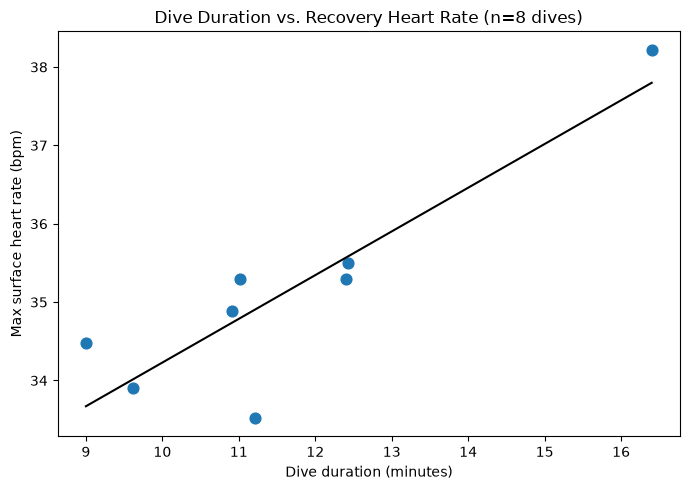

Chart Saved.


In [30]:
dive_model = LinearModel(model_name='Dive Duration -> Max Surface HR')
dive_model.fit(dive_summary['dive_duration'], dive_summary['max_surface_heart_rate'])
dive_model.print_model_info()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    dive_summary['dive_duration'], 
    dive_summary['max_surface_heart_rate'],
    color='C0',
    s=60
)

dive_model.plot_model(
    dive_summary['dive_duration'].min(), 
    dive_summary['dive_duration'].max()
)

ax.set_xlabel('Dive duration (minutes)')
ax.set_ylabel('Max surface heart rate (bpm)')
ax.set_title('Dive Duration vs. Recovery Heart Rate (n=8 dives)')
plt.tight_layout()

plt.savefig('../images/plots/dive_duration_vs_surface_hr.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart Saved.")